# Sales Data Dashboard

## Project Overview

This project analyzes sales data to understand business performance through key performance indicators, sales trends, regional performance, category performance, and product-level analysis.

## Objectives

* Analyze overall sales and profit performance.
* Track sales trends over time.
* Compare sales across different regions.
* Analyze sales and profit by product category.
* Identify top-performing products.
* Generate business insights using data visualization.

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../Dataset/sales_data.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   08/11/16  11/11/16    Second Class    CG-12520   
1       2  CA-2016-152156   08/11/16  11/11/16    Second Class    CG-12520   
2       3  CA-2016-138688   12/06/16  16/06/16    Second Class    DV-13045   
3       4  US-2015-108966   11/10/15  18/10/15  Standard Class    SO-20335   
4       5  US-2015-108966   11/10/15  18/10/15  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [4]:
print("Dataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

In [5]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Check the converted date columns
print("Date conversion completed!")
print(df[["Order Date", "Ship Date"]].head())

# Sort data by Order Date
df = df.sort_values("Order Date")

print("\nData preparation completed!")

Date conversion completed!
  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16
3 2015-10-11 2015-10-18
4 2015-10-11 2015-10-18

Data preparation completed!


C:\Users\HP\AppData\Local\Temp\ipykernel_26428\182996667.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_26428\182996667.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)


In [6]:
# Calculate key performance indicators

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()

print("SALES DASHBOARD KPIs")
print("=" * 30)
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")

SALES DASHBOARD KPIs
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity Sold: 37,873
Total Orders: 5,009


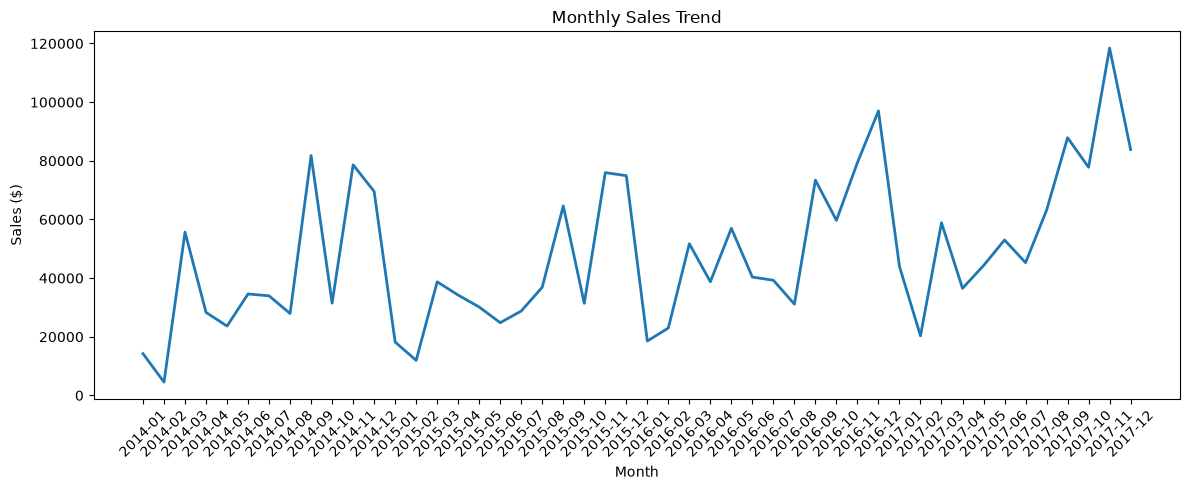

In [7]:
# Calculate monthly sales
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

# Create the sales trend chart
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)

plt.tight_layout()

# Save the chart
plt.savefig("../Images/monthly_sales_trend.png", dpi=300)

plt.show()

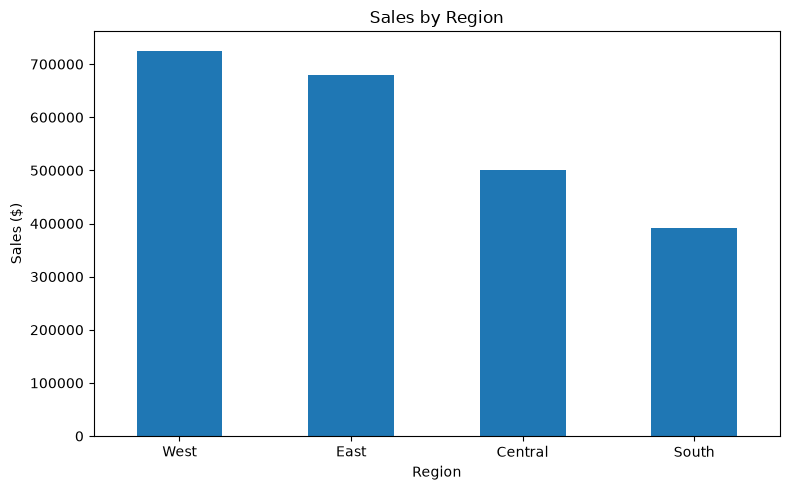

In [8]:
# Calculate sales by region
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Create the region sales chart
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig("../Images/sales_by_region.png", dpi=300)

plt.show()

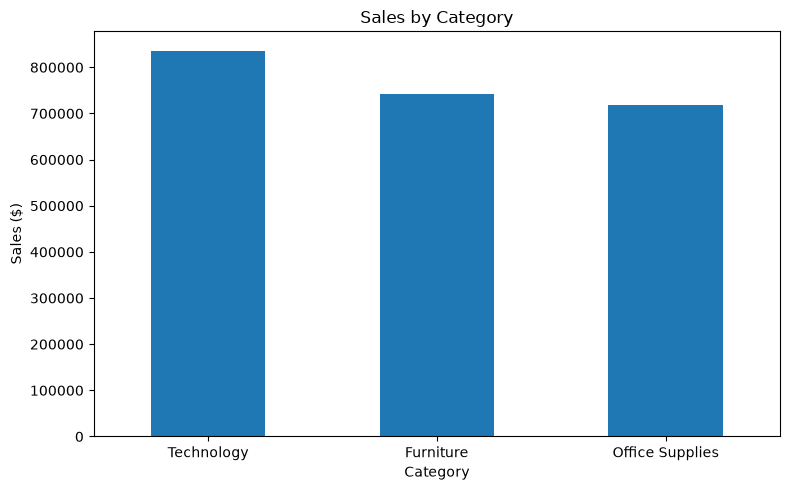

In [9]:
# Calculate sales by category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Create category sales chart
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig("../Images/sales_by_category.png", dpi=300)

plt.show()

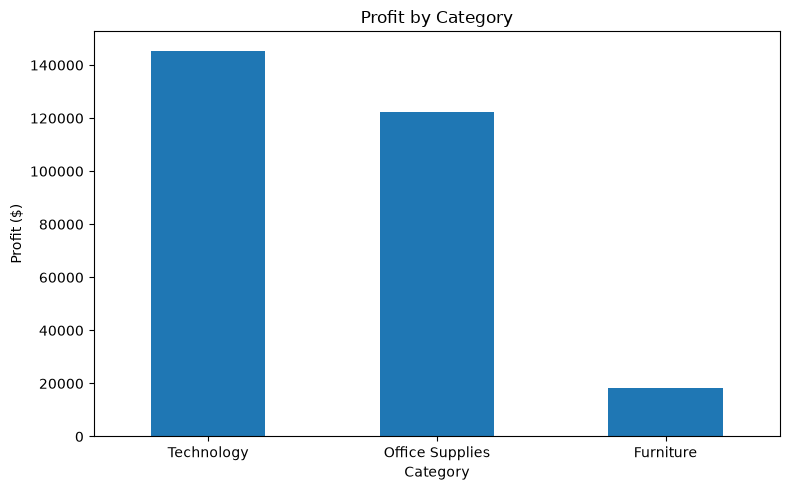

In [10]:
# Calculate profit by category
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

# Create profit chart
plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig("../Images/profit_by_category.png", dpi=300)

plt.show()

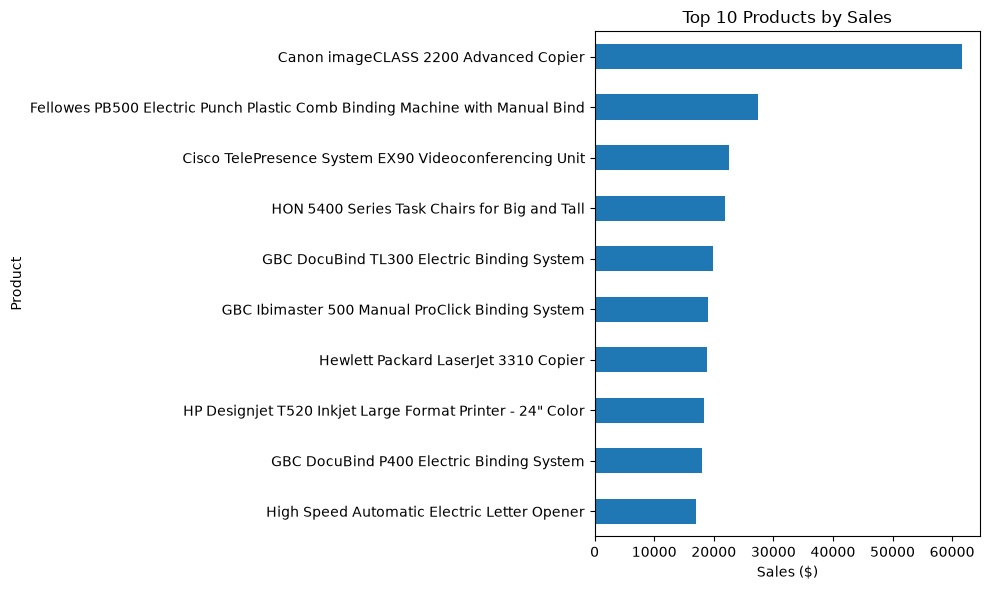

In [11]:
# Calculate top 10 products by sales
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

# Create chart
plt.figure(figsize=(10, 6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")

plt.tight_layout()

# Save the chart
plt.savefig("../Images/top_10_products.png", dpi=300)

plt.show()

In [12]:
print("SALES DATA DASHBOARD — KEY INSIGHTS")
print("=" * 45)

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Quantity Sold: {total_quantity:,}")

print("\nHighest Sales Region:")
print(region_sales.idxmax(), f"(${region_sales.max():,.2f})")

print("\nHighest Sales Category:")
print(category_sales.idxmax(), f"(${category_sales.max():,.2f})")

print("\nHighest Profit Category:")
print(category_profit.idxmax(), f"(${category_profit.max():,.2f})")

print("\nTop Product by Sales:")
print(top_products.idxmax(), f"(${top_products.max():,.2f})")

SALES DATA DASHBOARD — KEY INSIGHTS
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Quantity Sold: 37,873

Highest Sales Region:
West ($725,457.82)

Highest Sales Category:
Technology ($836,154.03)

Highest Profit Category:
Technology ($145,454.95)

Top Product by Sales:
Canon imageCLASS 2200 Advanced Copier ($61,599.82)


## Conclusion

The Sales Data Dashboard provided an overview of business performance using key sales and profit metrics, time-based trends, regional comparisons, category analysis, and top-product analysis.

The dataset contained 9,994 sales records. The analysis calculated total sales of $2,297,200.86, total profit of $286,397.02, 5,009 orders, and 37,873 units sold.

The West region recorded the highest sales among the regions analyzed, while Technology was the highest-performing category in both sales and profit. The analysis also identified the top product by sales.

This project demonstrates how Python-based data analysis and visualization can transform raw sales data into meaningful business insights that can support decision-making.
